In [11]:
import random
import logging
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import copy
from tqdm.auto import tqdm
import itertools
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
import pickle
from osl_dynamics.data import Data
from osl_dynamics.data import processing
from osl_dynamics.models.hmm import Config
from osl_dynamics.models.hmm import Model
from osl_dynamics.models import load
from osl_dynamics.utils import plotting
from osl_dynamics.inference import modes

In [12]:
random.seed(42)
np.random.seed(42)

# Prepare Data

In [13]:
# Silence unnecessary messages
_logger = logging.getLogger("osl-dynamics")
_logger.setLevel(logging.CRITICAL + 1)

In [28]:
# # Load data
# data_path = '../../CIMT_data/azad_timecourse_csv_no_wm_z_scored' # rsfMRI
# X = []
# y = []
# group_freq = {}
# PID_freq = {}
# subj_freq = {}
# for tc in sorted(os.listdir(data_path)):
#     X.append(np.loadtxt(os.path.join(data_path, tc), delimiter=',', skiprows=1))
#     y.append(tc[:12])
#     group_freq[tc[:12]] = 1 + group_freq.get(tc[:12], 0)
#     PID_freq[tc[9:12]] = 1 + PID_freq.get(tc[9:12], 0)
#     subj_freq[tc[14:16]] = 1 + subj_freq.get(tc[14:16], 0)

# X = np.array(X) # X.shape = (subjects, timepoints, ROIs)
# y = np.array(y)
# print(X.shape)
# print(y.shape)

(114, 450, 114)
(114,)


In [6]:
print(X[0].shape)
print(np.prod(X[0].shape)) # n_samples = timepoints * subjects

(450, 114)
51300
[-2.68790838e-16  1.01755650e-15 -1.49860631e-15  8.23693507e-16
 -1.91119483e-15 -6.44189056e-16  1.96216662e-15 -1.16154987e-15
  2.07798258e-15  2.68416435e-16  1.84511330e-15  1.19973340e-16
  1.26615201e-15 -2.02995515e-16  1.14511011e-15  6.67302471e-17
  6.61604191e-16 -2.04314987e-15 -2.59444188e-15  9.76314005e-16
  1.19505878e-15 -1.69447113e-15 -5.72468215e-17 -1.40290422e-15
  5.44052566e-16 -1.75106626e-15  1.80180540e-15  7.90258047e-16
 -5.85591111e-16  2.77742958e-16  4.39557422e-16  7.80475965e-16
  8.10194450e-16 -2.46098139e-15  6.91654877e-16  1.05681302e-15
 -4.70080981e-16 -2.65088579e-15 -1.42702830e-15 -3.70342267e-15
  1.30902328e-15 -3.46108673e-15  1.52810729e-15 -3.60464312e-15
 -1.87202539e-15 -5.06610673e-16  3.08374076e-15 -1.11374090e-15
  3.41871863e-16 -9.05071989e-16  3.75731501e-16  3.13831698e-16
  4.89907010e-16  3.90917102e-15  2.47478559e-15 -2.50488389e-16
 -1.50174734e-15  3.56896232e-15 -1.96825445e-15  1.86580459e-15
  1.4427

In [7]:
np.unique(y)

array(['CCI_CIMT_07d', 'CCI_CIMT_21d', 'CCI_CIMT_49d', 'CCI_none_07d',
       'CCI_none_21d', 'CCI_none_49d', 'SHM_none_07d', 'SHM_none_21d',
       'SHM_none_49d'], dtype='<U12')

In [7]:
full_data = Data(X)
print(full_data)

Loading files:   0%|          | 0/114 [00:00<?, ?it/s]

Data
 id: 13306656672
 n_sessions: 114
 n_samples: 51300
 n_channels: 114


# Determine Number of Principal Components

In [8]:
# start with 6-10 sec window, TR=2 sec

In [9]:
arrays = copy.deepcopy(full_data.arrays)
n_channels = arrays[0].shape[-1]
covariance = np.zeros([n_channels, n_channels])
for array in tqdm(arrays, desc="Calculating PCA components"):
    std_data = processing.standardize(array)
    covariance += np.transpose(std_data) @ std_data

s = np.linalg.svd(covariance, compute_uv=False) # since covariance is symmetric and PSD, its singular values equal its eigenvalues
exp_var = s / np.sum(s)
exp_var

Calculating PCA components:   0%|          | 0/114 [00:00<?, ?it/s]

array([0.21049754, 0.04753846, 0.03884433, 0.03447638, 0.02991784,
       0.02427274, 0.02132397, 0.01955523, 0.01811396, 0.01666466,
       0.01561889, 0.0142921 , 0.01380057, 0.01256233, 0.0117972 ,
       0.01117582, 0.01099318, 0.01094061, 0.01021609, 0.0100977 ,
       0.00989731, 0.00972012, 0.00929758, 0.00899806, 0.00883121,
       0.00852894, 0.0081697 , 0.00802377, 0.00788971, 0.00774843,
       0.00734321, 0.00727014, 0.00720644, 0.00705161, 0.00698667,
       0.00675984, 0.00666908, 0.00654715, 0.00647952, 0.00637795,
       0.00613512, 0.00609323, 0.00601906, 0.00593493, 0.00576105,
       0.00569071, 0.00562438, 0.0054738 , 0.00536977, 0.00534315,
       0.00526769, 0.005222  , 0.00516706, 0.00513178, 0.00503283,
       0.00489933, 0.00484414, 0.00479188, 0.00469194, 0.00463832,
       0.00453207, 0.00450645, 0.00444491, 0.00437888, 0.00431394,
       0.0042477 , 0.00413878, 0.00406248, 0.00392892, 0.00388509,
       0.00386649, 0.00375735, 0.00371392, 0.0036608 , 0.00361

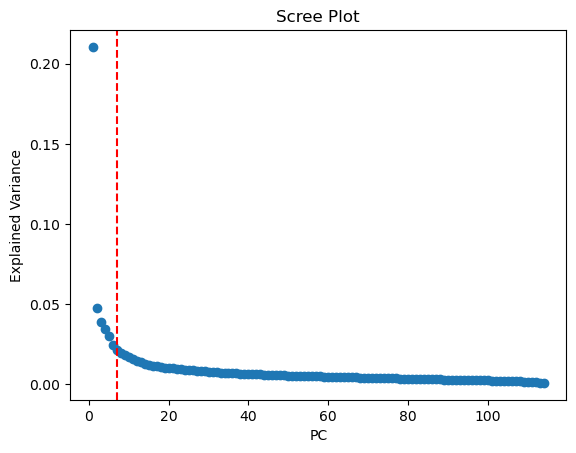

In [10]:
# Make scree plot
max_n_pca_components = n_channels # number of PCs to display
fig, ax = plt.subplots(1, 1)
x = [i for i in range(1, max_n_pca_components + 1)]
ax.scatter(x, exp_var[:max_n_pca_components])
ax.axvline(x=7, color='r', linestyle='--')

ax.set_title("Scree Plot")
ax.set_xlabel("PC")
ax.set_ylabel("Explained Variance")
plt.show()

So it seems that going beyond PC 7 has diminishing returns

In [11]:
n_pca_components = 7 # using all 114 regions results in hella overfitting, better run PCA!

In [12]:
full_data.prepare({
    # "pca": {"n_pca_components": n_pca_components},
    "standardize": {},
})

Calculating PCA components:   0%|          | 0/114 [00:00<?, ?it/s]

PCA:   0%|          | 0/114 [00:00<?, ?it/s]

Standardize:   0%|          | 0/114 [00:00<?, ?it/s]

In [13]:
full_data_full_seq = copy.deepcopy(full_data) # just in case .dataset() modifies original data
full_data_full_seq = full_data_full_seq.dataset(sequence_length=450, batch_size=full_data_full_seq.n_sessions) # ensure consistent evaluation across models of different sequence_length

### We can load the prepared data by simply passing the path to the directory to the Data class

# Create Folds

In [14]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits)

In [15]:
split_plan = {
    'outer_train': [],
    'outer_test': [],
    'inner_train': [],
    'inner_val': [],
}

for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"Fold {i + 1}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")
    
    outer_train, outer_test, y_train, y_test = X[train_index,], X[test_index,], y[train_index,], y[test_index,]
    
    # Check for even splits within groups  
    print(np.sum(y_test == "CCI_CIMT_07d") / np.sum(y == "CCI_CIMT_07d"))
    print(np.sum(y_test == "CCI_CIMT_21d") / np.sum(y == "CCI_CIMT_21d"))
    print(np.sum(y_test == "CCI_CIMT_49d") / np.sum(y == "CCI_CIMT_49d"))
    print(np.sum(y_test == "CCI_none_07d") / np.sum(y == "CCI_none_07d"))
    print(np.sum(y_test == "CCI_none_21d") / np.sum(y == "CCI_none_21d"))
    print(np.sum(y_test == "CCI_none_49d") / np.sum(y == "CCI_none_49d"))
    print(np.sum(y_test == "SHM_none_07d") / np.sum(y == "SHM_none_07d"))
    print(np.sum(y_test == "SHM_none_21d") / np.sum(y == "SHM_none_21d"))
    print(np.sum(y_test == "SHM_none_49d") / np.sum(y == "SHM_none_49d"))
    
    inner_train, inner_val, y_inner_train, y_inner_val = train_test_split(outer_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
    
    outer_train = Data(outer_train)
    outer_test = Data(outer_test)
    inner_train = Data(inner_train)
    inner_val = Data(inner_val)
    
    outer_train.prepare({
        "pca": {"n_pca_components": n_pca_components},
        "standardize": {},
    })
    outer_test.prepare({
        "pca": {"pca_components": outer_train.pca_components},
        "standardize": {},
    })
    outer_test = outer_test.dataset(sequence_length=450, batch_size=outer_test.n_sessions) # ensure consistent evaluation across models of different sequence_length

    inner_train.prepare({
        "pca": {"n_pca_components": n_pca_components},
        "standardize": {},
    })
    inner_val.prepare({
        "pca": {"pca_components": inner_train.pca_components},
        "standardize": {},
    })

    split_plan['outer_train'].append(outer_train)
    split_plan['outer_test'].append(outer_test)
    split_plan['inner_train'].append(inner_train)
    split_plan['inner_val'].append(inner_val)

Fold 1:
  Train: index=[  3   4   5   6   7   8   9  10  11  12  13  14  18  19  20  21  22  23
  24  25  26  27  28  29  33  34  35  36  37  38  39  40  41  42  43  44
  48  49  50  51  52  53  54  55  56  57  58  59  63  64  65  66  67  68
  69  70  71  72  76  77  78  79  80  81  82  83  84  85  86  87  90  91
  92  93  94  95  97  98  99 100 101 102 103 104 107 108 109 110 111 112
 113]
  Test:  index=[  0   1   2  15  16  17  30  31  32  45  46  47  60  61  62  73  74  75
  88  89  96 105 106]
0.2
0.2
0.2
0.2
0.23076923076923078
0.2
0.25
0.1111111111111111
0.2222222222222222


Loading files:   0%|          | 0/91 [00:00<?, ?it/s]

Loading files:   0%|          | 0/23 [00:00<?, ?it/s]

Loading files:   0%|          | 0/72 [00:00<?, ?it/s]

Loading files:   0%|          | 0/19 [00:00<?, ?it/s]

...

Calculating PCA components:   0%|          | 0/73 [00:00<?, ?it/s]

PCA:   0%|          | 0/73 [00:00<?, ?it/s]

Standardize:   0%|          | 0/73 [00:00<?, ?it/s]

PCA:   0%|          | 0/19 [00:00<?, ?it/s]

Standardize:   0%|          | 0/19 [00:00<?, ?it/s]

# HMM Training

In [16]:
def get_param_combinations(param_grid):
    combinations = itertools.product(*param_grid.values())
    return [dict(zip(param_grid.keys(), combination)) for combination in combinations]

In [17]:
def rank_runs(log):
    return sorted(list(zip(log['params'], log['history'])), key=lambda trial: min(trial[1]['val_loss'])) # rank in increasing order of minimum val_loss

If you see <code>I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence</code>, it just means that the pipeline hit the end of the dataset

In [18]:
# def grid_search(param_grid, train_data, val_data, log):
#     i = 1
#     for params in get_param_combinations(param_grid):
#         log['params'].append(params)
#         print(f"Param Set {i}: {params}")
        
#         config = Config(
#             n_states=params['n_states'],
#             n_channels=train_data.n_channels,
#             sequence_length=params['sequence_length'],
#             learn_means=False,
#             learn_covariances=True,
#             batch_size=params['batch_size'],
#             learning_rate=params['learning_rate'],
#             n_epochs=params['n_epochs'],
#         )
        
#         model = Model(config)
#         model.random_state_time_course_initialization(train_data, n_epochs=1, n_init=3, verbose=0)
#         callback = EarlyStopping(monitor='val_loss', patience=5, verbose=0)
#         history = model.fit(
#             train_data,
#             validation_data=val_data.dataset(
#                 sequence_length=params['sequence_length'],
#                 batch_size=params['batch_size'],
#             ),
#             verbose=0,
#             callbacks=[callback],
#         )
#         log['history'].append(history)
        
#         i += 1

In [48]:
def plot_loss(res, f_idx):
    fig, ax = plt.subplots(1, 1)
    x = range(1, len(res['histories'][f_idx]['loss']) + 1)
    ax.plot(x, res['histories'][f_idx]['loss'], label="Training Loss", color='blue', linestyle='-')
    ax.plot(x, res['histories'][f_idx]['val_loss'], label="Validation Loss", color='orange', linestyle='--')

    ax.set_title(str(res['best_params'][f_idx]))
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (Free Energy)")
    ax.legend()
    
    plt.show()

In [20]:
full_data.recommend_model_config()

Recommendation:
  config = Config(
      ...
      sequence_length=200,
      batch_size=57,
      learning_rate=0.01,
      n_epochs=20,
  )
Total number of sequences: 228
Total number of batches/parameter updates: 4


In [21]:
param_grid_no_TDE = {
    'sequence_length': [200],
    'batch_size': [57],
    'learning_rate': [0.01], 
    'n_epochs': [20, 30, 40, 50, 60, 70, 80, 90, 100], # added more options to check for possible further improvement past 20 epochs
}

## Approach 1: Test Evidence

In [21]:
# best_params_no_TDE = {} # n: {'best_params': [], 'histories': [], 'test_free_energies': []}

In [23]:
# with open('grid_search/best_params_no_TDE.pkl', 'rb') as f:
#     best_params_no_TDE = pickle.load(f)

# print(best_params_no_TDE.keys())

dict_keys([6, 7, 8, 9, 10])


In [24]:
min_n_states = 11 # must be >= 2
max_n_states = 14
param_grid = param_grid_no_TDE
best_params_log = best_params_no_TDE
for n in range(min_n_states, max_n_states + 1):
    print(f"\nGrid searching with {n} states...")
    if n not in best_params_log:
        best_params_log[n] = {
            'best_params': [], 
            'histories': [], 
            'test_evidences': [],
        }
    
    for f in range(n_splits):
        print(f"\nFold {f + 1}...")
        outer_train, outer_test, inner_train, inner_val = split_plan['outer_train'][f], split_plan['outer_test'][f], split_plan['inner_train'][f], split_plan['inner_val'][f]
        outer_test = outer_test.dataset(sequence_length=450, batch_size=outer_test.n_sessions) # ensure consistent evaluation across models of different sequence_length
        fold_log = {
            'params': [],
            'history': [],
        }

        i = 1
        for params in get_param_combinations(param_grid):
            fold_log['params'].append(params)
            print(f"Param set {i}: {params}")
            
            config = Config(
                n_states=n,
                n_channels=inner_train.n_channels,
                sequence_length=params['sequence_length'],
                learn_means=False,
                learn_covariances=True,
                batch_size=params['batch_size'],
                learning_rate=params['learning_rate'],
                n_epochs=params['n_epochs'],
            )
            
            model = Model(config)
            model.random_state_time_course_initialization(inner_train, n_epochs=1, n_init=3, verbose=0)
            callback = EarlyStopping(monitor='val_loss', patience=5, verbose=0) # we don't need restore_best_weights=True because we aren't saving the models
            history = model.fit(
                inner_train,
                validation_data=inner_val.dataset(
                    sequence_length=params['sequence_length'],
                    batch_size=params['batch_size'],
                ),
                verbose=0,
                callbacks=[callback],
            )
            fold_log['history'].append(history)
            
            i += 1

        if len(best_params_log[n]['best_params']) >= f + 1: # if there already exists a "best" param set for fold f, include it in the ranking
            fold_log['params'].append(best_params_log[n]['best_params'][f])
            fold_log['history'].append(best_params_log[n]['histories'][f])
            
        best_run = rank_runs(fold_log)[0]
        best_run_params = best_run[0]
        print(f"Best param set: {best_run_params}")
        if len(best_params_log[n]['best_params']) < f + 1 or best_run_params != best_params_log[n]['best_params'][f]:   
            best_config = Config(
                n_states=n,
                n_channels=outer_train.n_channels,
                sequence_length=best_run_params['sequence_length'],
                learn_means=False,
                learn_covariances=True,
                batch_size=best_run_params['batch_size'],
                learning_rate=best_run_params['learning_rate'],
                n_epochs=best_run_params['n_epochs'],
                loss_calc='mean', # to get the average per-timepoint log likelihood when computing test evidence
            )
    
            best_model = Model(best_config)
            best_model.random_state_time_course_initialization(outer_train, n_epochs=1, n_init=3, verbose=0)
            best_model.fit(
                outer_train,
                verbose=0,
            )

            best_run_history = best_run[1]
            test_evidence = best_model.evidence(outer_test) # free energy only provides an approximation of model evidence, so use model evidence if available

            if len(best_params_log[n]['best_params']) < f + 1:
                best_params_log[n]['best_params'].append(best_run_params)
                best_params_log[n]['histories'].append(best_run_history)
                best_params_log[n]['test_evidences'].append(test_evidence)
            else:
                best_params_log[n]['best_params'][f] = best_run_params
                best_params_log[n]['histories'][f] = best_run_history
                best_params_log[n]['test_evidences'][f] = test_evidence


Grid searching with 11 states...

Fold 1...
Param set 1: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 20}


2025-10-25 14:30:33.774142: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-10-25 14:30:36.414044: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2025-10-25 14:30:43 WARNING tensorflow [polymorphic_function.py:157:called_with_tracing]: 5 out of the last 13 calls to <function TensorFlowTrainer._make_function.<locals>.multi_step_on_iterator at 0x36275b240> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


Param set 2: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 30}


2025-10-25 14:30:46.263885: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

Getting evidence; Test data sequence length: 450:   0%|          | 0/1 [00:00<?, ?it/s]


Fold 4...
Param set 1: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 20}
Param set 2: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 30}
Param set 3: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 40}
Param set 4: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 50}
Param set 5: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 60}
Param set 6: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 70}
Param set 7: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 80}
Param set 8: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 90}
Param set 9: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 100}
Best param set: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 60}


Getting evidence; Test data sequence length: 450:   0%|          | 0/1 [00:00<?, ?it/s]


Fold 5...
Param set 1: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 20}
Param set 2: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 30}
Param set 3: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 40}
Param set 4: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 50}
Param set 5: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 60}
Param set 6: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 70}
Param set 7: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 80}
Param set 8: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 90}
Param set 9: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 100}
Best param set: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 50}


Getting evidence; Test data sequence length: 450:   0%|          | 0/1 [00:00<?, ?it/s]

In [25]:
sorted(best_params_no_TDE.keys())

[6, 7, 8, 9, 10, 11, 12, 13, 14]

In [26]:
with open('grid_search/best_params_no_TDE.pkl', 'wb') as f:
    pickle.dump(best_params_no_TDE, f)

In [27]:
# os.makedirs("grid_search", exist_ok=True)

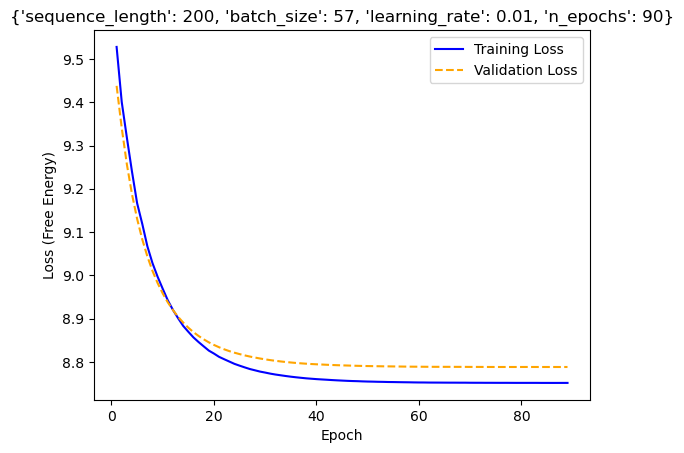

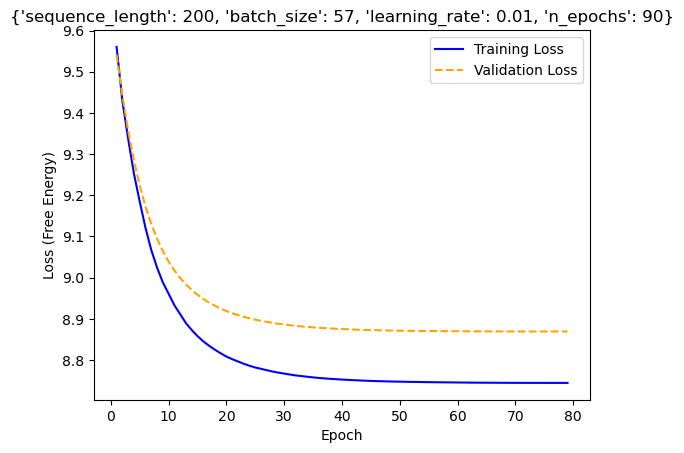

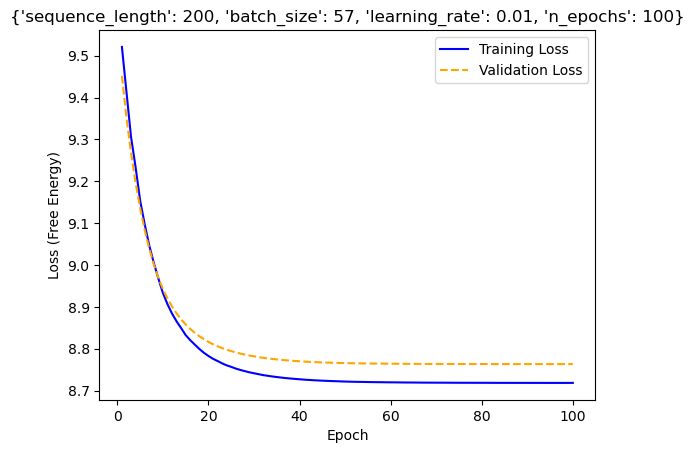

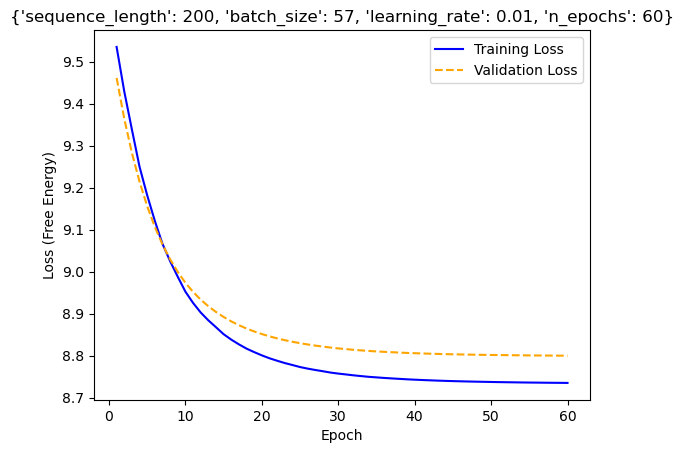

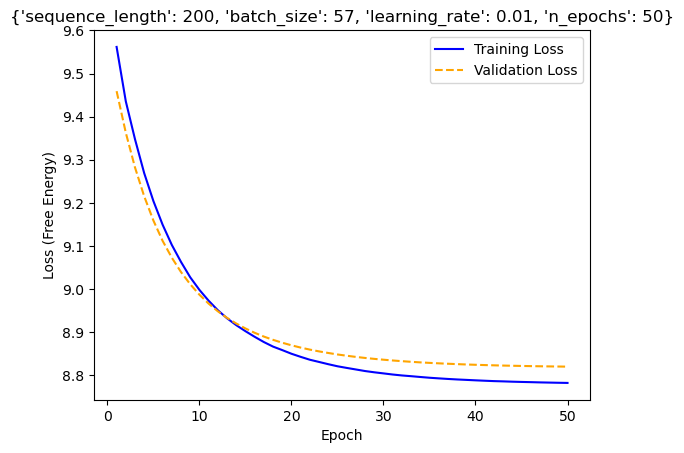

In [73]:
for f in range(n_splits):
    plot_loss(best_params_no_TDE[14], f)

In [34]:
one_se_rule = {}

for key, value in best_params_no_TDE.items():
    one_se_rule[key] = {
        'mean': np.mean(value['test_evidences']),
        'se': np.std(value['test_evidences'], ddof=1) / np.sqrt(n_splits),
    }

In [35]:
one_se_rule

{6: {'mean': np.float32(-9.418562), 'se': np.float64(0.017046503467287144)},
 7: {'mean': np.float32(-9.373205), 'se': np.float64(0.016920075689722227)},
 8: {'mean': np.float32(-9.337015), 'se': np.float64(0.021974952685690472)},
 9: {'mean': np.float32(-9.305757), 'se': np.float64(0.0190765250383448)},
 10: {'mean': np.float32(-9.271992), 'se': np.float64(0.019082172779933546)},
 11: {'mean': np.float32(-9.264789), 'se': np.float64(0.016976538111605453)},
 12: {'mean': np.float32(-9.212786), 'se': np.float64(0.02142513254702266)},
 13: {'mean': np.float32(-9.2032795), 'se': np.float64(0.023813948977011536)},
 14: {'mean': np.float32(-9.177676), 'se': np.float64(0.024654639469502984)}}

In [36]:
sorted_by_n = sorted(list(one_se_rule.items()), key=lambda x: x[0])
sorted_by_n

[(6, {'mean': np.float32(-9.418562), 'se': np.float64(0.017046503467287144)}),
 (7, {'mean': np.float32(-9.373205), 'se': np.float64(0.016920075689722227)}),
 (8, {'mean': np.float32(-9.337015), 'se': np.float64(0.021974952685690472)}),
 (9, {'mean': np.float32(-9.305757), 'se': np.float64(0.0190765250383448)}),
 (10, {'mean': np.float32(-9.271992), 'se': np.float64(0.019082172779933546)}),
 (11, {'mean': np.float32(-9.264789), 'se': np.float64(0.016976538111605453)}),
 (12, {'mean': np.float32(-9.212786), 'se': np.float64(0.02142513254702266)}),
 (13,
  {'mean': np.float32(-9.2032795), 'se': np.float64(0.023813948977011536)}),
 (14, {'mean': np.float32(-9.177676), 'se': np.float64(0.024654639469502984)})]

In [43]:
search_space = range(6, 12)
sorted_by_mean = sorted([x for x in sorted_by_n if x[0] in search_space], key=lambda x: x[1]['mean'], reverse=True)
sorted_by_mean

[(11, {'mean': np.float32(-9.264789), 'se': np.float64(0.016976538111605453)}),
 (10, {'mean': np.float32(-9.271992), 'se': np.float64(0.019082172779933546)}),
 (9, {'mean': np.float32(-9.305757), 'se': np.float64(0.0190765250383448)}),
 (8, {'mean': np.float32(-9.337015), 'se': np.float64(0.021974952685690472)}),
 (7, {'mean': np.float32(-9.373205), 'se': np.float64(0.016920075689722227)}),
 (6, {'mean': np.float32(-9.418562), 'se': np.float64(0.017046503467287144)})]

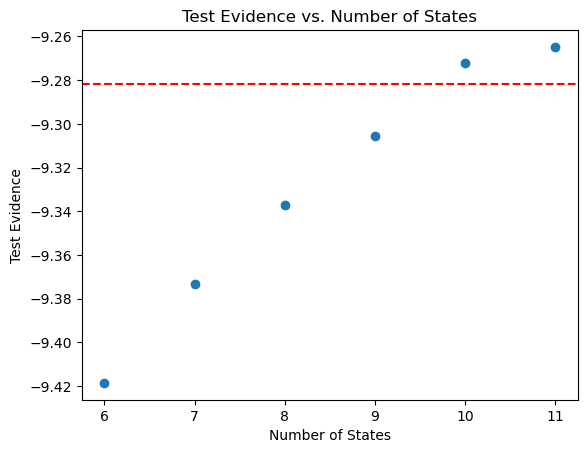

In [44]:
fig, ax = plt.subplots(1, 1)
n_states = [x[0] for x in sorted_by_mean]
mean_test_evidence = [x[1]['mean'] for x in sorted_by_mean]
ax.scatter(n_states, mean_test_evidence)
ax.axhline(y=sorted_by_mean[0][1]['mean'] - sorted_by_mean[0][1]['se'], color='r', linestyle='--')

ax.set_title("Test Evidence vs. Number of States")
ax.set_xlabel("Number of States")
ax.set_ylabel("Test Evidence")

plt.show()

## Approach 2: BIC

In [22]:
hyperparam_CV_no_TDE = {}

In [54]:
pkl_name = "hyperparam_CV_no_TDE"

In [55]:
if os.path.exists(f'grid_search/{pkl_name}.pkl'):
    with open(f'grid_search/{pkl_name}.pkl', 'rb') as f:
        hyperparam_CV_no_TDE = pickle.load(f)

sorted(hyperparam_CV_no_TDE.keys())

[6, 7, 8, 9, 10, 11, 12, 13, 14]

In [56]:
hyperparam_CV_log = hyperparam_CV_no_TDE

In [30]:
# CV to determine optimal hyperparameters for each number of states n
min_n_states = 12 # must be >= 2
max_n_states = 14
param_grid = param_grid_no_TDE
for n in range(min_n_states, max_n_states + 1):
    print(f"\nGrid searching with {n} states...")
    if n not in hyperparam_CV_log:
        hyperparam_CV_log[n] = {
            'params': [], # {params}
            'histories': [], # [history object for each fold]
            'test_evidences': [], # float
        }

    i = 1
    for params in get_param_combinations(param_grid):
        print(f"Param set {i}: {params}")
        histories = []
        test_evidences = []
        for f in range(n_splits):
            print(f"\nFold {f + 1}...")
            outer_test, inner_train, inner_val = split_plan['outer_test'][f], split_plan['inner_train'][f], split_plan['inner_val'][f]
        
            config = Config(
                n_states=n,
                n_channels=inner_train.n_channels,
                sequence_length=params['sequence_length'],
                learn_means=False,
                learn_covariances=True,
                batch_size=params['batch_size'],
                learning_rate=params['learning_rate'],
                n_epochs=params['n_epochs'],
                loss_calc='mean', # to get the average per-timepoint log likelihood when computing test evidence
            )
        
            model = Model(config)
            model.random_state_time_course_initialization(inner_train, n_epochs=1, n_init=3, verbose=0)
            callback = EarlyStopping(monitor='val_loss', patience=5, verbose=0) # we don't need restore_best_weights=True because we aren't saving the models
            history = model.fit(
                inner_train,
                validation_data=inner_val.dataset(
                    sequence_length=params['sequence_length'],
                    batch_size=params['batch_size'],
                ),
                verbose=0,
                callbacks=[callback],
            )
            histories.append(history)
                
            test_evidence = model.evidence(outer_test)
            test_evidences.append(test_evidence) 

        hyperparam_CV_log[n]['params'].append(params)
        hyperparam_CV_log[n]['histories'].append(histories)
        hyperparam_CV_log[n]['test_evidences'].append(test_evidences) # can take the mean across folds later

        i += 1


Grid searching with 12 states...
Param set 1: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 20}

Fold 1...


2025-10-26 16:35:33 WARNING tensorflow [polymorphic_function.py:157:called_with_tracing]: 5 out of the last 210 calls to <function TensorFlowTrainer._make_function.<locals>.multi_step_on_iterator at 0x3a98e60c0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


2025-10-26 16:35:34 WARNING tensorflow [polymorphic_function.py:157:called_with_tracing]: 5 out of the last 13 calls to <function TensorFlowTrainer._make_function.<locals>.multi_step_on_iterator at 0x3a58e4d60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


Getting evidence; Test data sequence length: 450:   0%|          | 0/1 [00:00<?, ?it/s]


Fold 2...


...

Getting evidence; Test data sequence length: 450:   0%|          | 0/1 [00:00<?, ?it/s]


Fold 4...


Getting evidence; Test data sequence length: 450:   0%|          | 0/1 [00:00<?, ?it/s]


Fold 5...


Getting evidence; Test data sequence length: 450:   0%|          | 0/1 [00:00<?, ?it/s]

In [36]:
sorted_states = sorted(hyperparam_CV_log.keys())
sorted_states

[6, 7, 8, 9, 10, 11, 12, 13, 14]

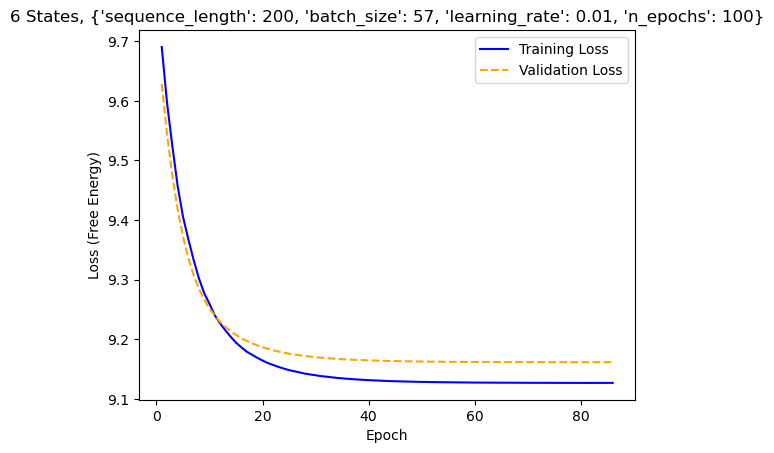

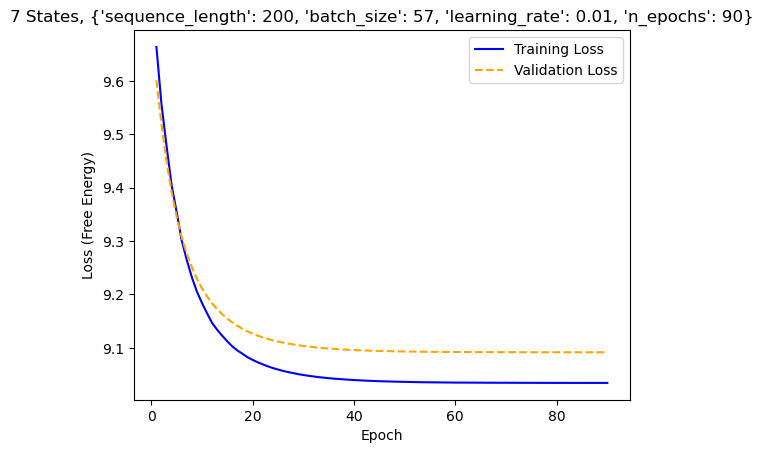

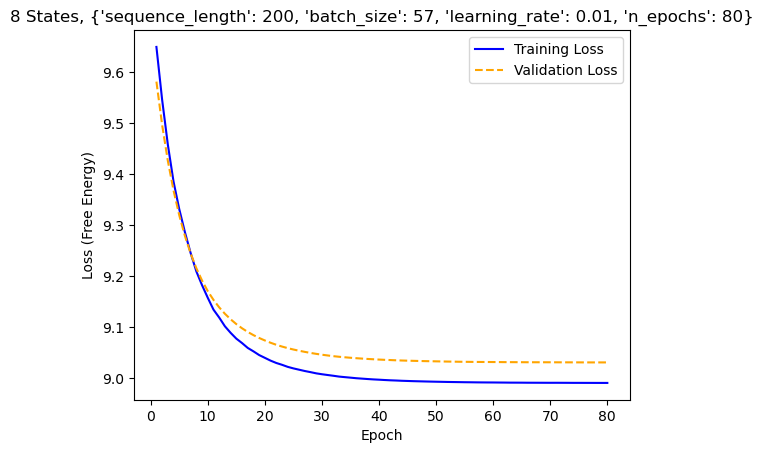

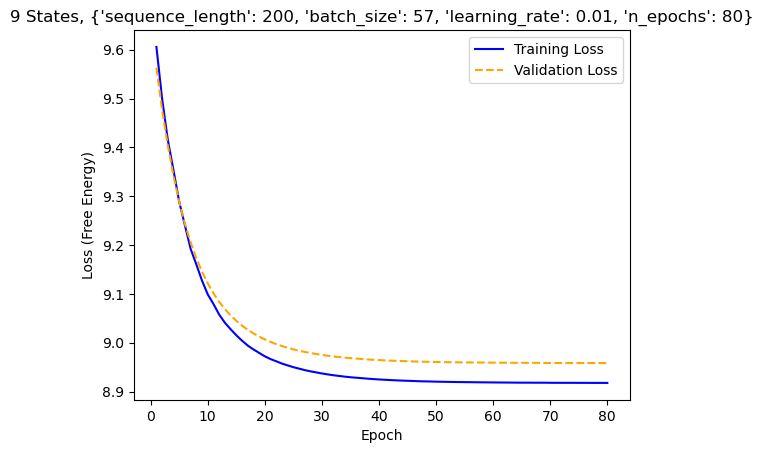

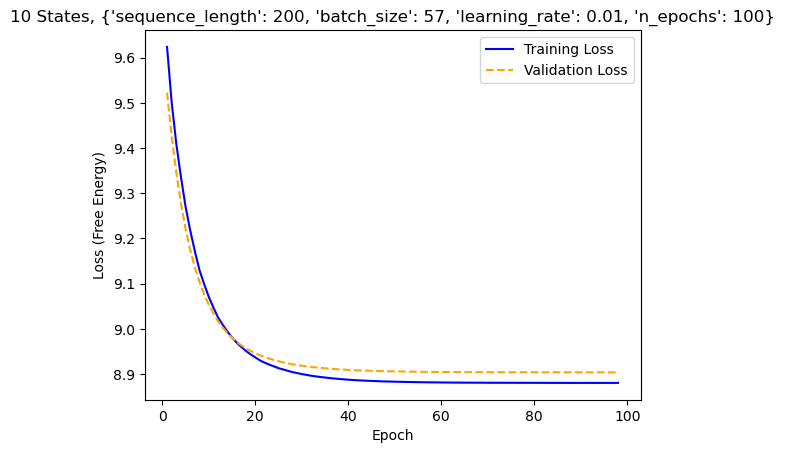

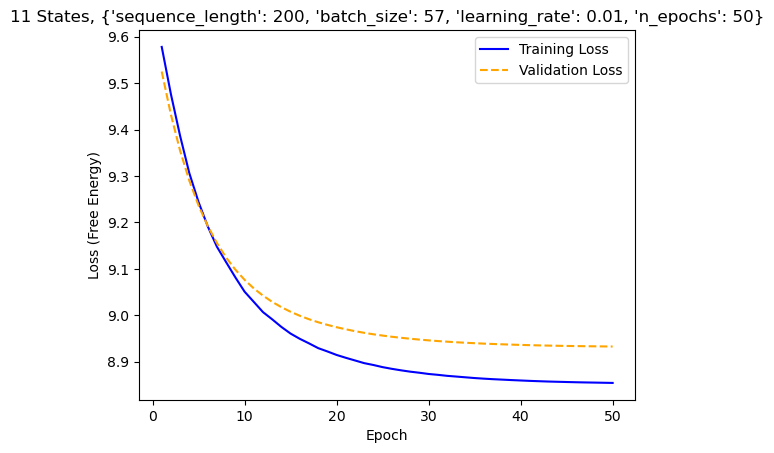

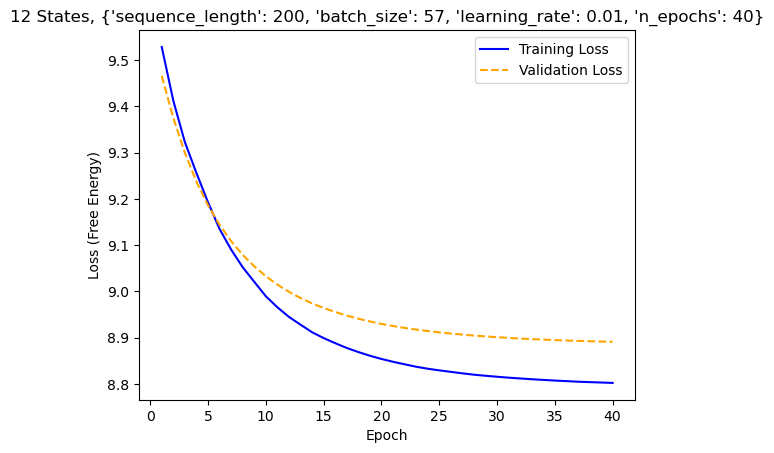

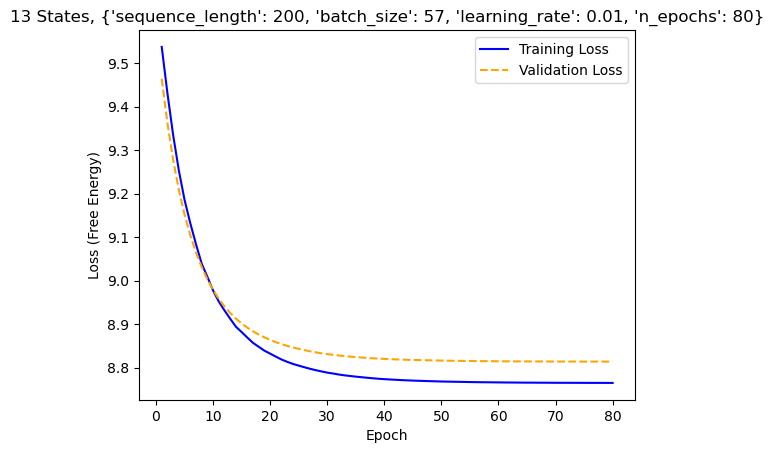

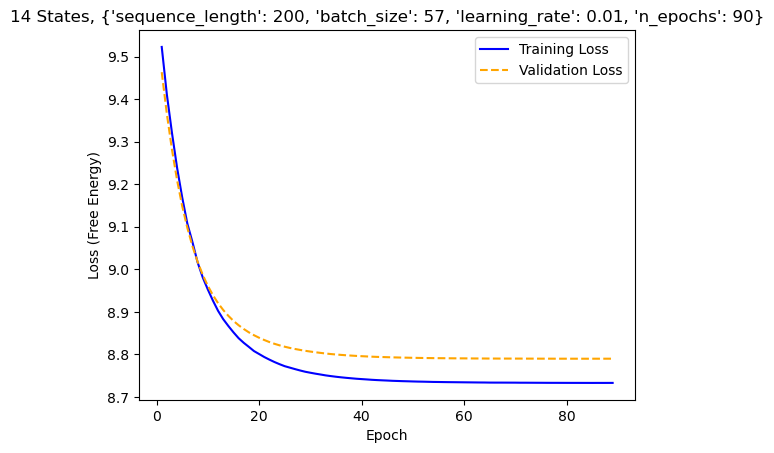

In [127]:
# Sanity check
f_idx = 0
for n in sorted_states:
    example = hyperparam_CV_log[n]['histories'][np.argmax(hyperparam_CV_log[n]['mean_CV_test_evidence'])]
    fig, ax = plt.subplots(1, 1)
    x = range(1, len(example[f_idx]['loss']) + 1)
    ax.plot(x, example[f_idx]['loss'], label="Training Loss", color='blue', linestyle='-')
    ax.plot(x, example[f_idx]['val_loss'], label="Validation Loss", color='orange', linestyle='--')

    ax.set_title(f"{n} States, " + str(hyperparam_CV_log[n]['params'][np.argmax(hyperparam_CV_log[n]['mean_CV_test_evidence'])]))
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (Free Energy)")
    ax.legend()
    plt.show()

In [59]:
with open(f'grid_search/{pkl_name}.pkl', 'wb') as f:
    pickle.dump(hyperparam_CV_log, f)

In [60]:
for n in sorted_states:
    print(f"Best params for {n} states: {hyperparam_CV_log[n]['params'][np.argmax(hyperparam_CV_log[n]['mean_CV_test_evidence'])]}")

Best params for 6 states: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 100}
Best params for 7 states: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 90}
Best params for 8 states: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 80}
Best params for 9 states: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 80}
Best params for 10 states: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 100}
Best params for 11 states: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 50}
Best params for 12 states: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 40}
Best params for 13 states: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 80}
Best params for 14 states: {'sequence_length': 200, 'batch_size': 57, 'learning_rate': 0.01, 'n_epochs': 90}


In [128]:
iters = 5

In [44]:
# Compute full-dataset evaluation metrics
for n in sorted_states:
    print(f"Fitting model with {n} states...")
    hyperparam_CV_log[n]['full_evidence'] = []
    hyperparam_CV_log[n]['BIC'] = []
    hyperparam_CV_log[n]['ICL'] = []
    for i in range(iters): # account for variability in .random_state_time_course_initialization(), then average later
        print(f"Iteration {i + 1}:")
        best_params = hyperparam_CV_log[n]['params'][np.argmax(hyperparam_CV_log[n]['mean_CV_test_evidence'])]
        config = Config(
            n_states=n,
            n_channels=full_data.n_channels,
            sequence_length=best_params['sequence_length'],
            learn_means=False,
            learn_covariances=True,
            batch_size=best_params['batch_size'],
            learning_rate=best_params['learning_rate'],
            n_epochs=best_params['n_epochs'],
            loss_calc='mean', # to get the average per-timepoint log likelihood when computing test evidence
        )
        
        model = Model(config)
        model.random_state_time_course_initialization(full_data, n_epochs=1, n_init=3, verbose=0)
        history = model.fit(full_data, verbose=0)
    
        mean_per_timepoint_LL = model.evidence(full_data_full_seq)
        hyperparam_CV_log[n]['full_evidence'].append(mean_per_timepoint_LL)
    
        # Compute BIC
        total_LL = mean_per_timepoint_LL * full_data.n_samples
        d = n_pca_components
        k = (n - 1) + n * (n - 1) + n * (d + (d * (d + 1)) / 2) # number of estimated parameters
        BIC = k * np.log(full_data.n_samples) - 2 * total_LL
        hyperparam_CV_log[n]['BIC'].append(BIC)
    
        # Compute ICL (integrated completed likelihood)
        pred_data = copy.deepcopy(full_data)
        pred_data = pred_data.dataset(sequence_length=model.config.sequence_length, batch_size=full_data.n_sessions)
        entropies = []
        for batch in tqdm(pred_data, desc="Computing posterior entropy..."):
            pred = model.predict(batch, verbose=0)
            entropy = model.get_posterior_entropy(pred['gamma'], pred['xi']) 
            entropies.append(entropy)
            
        posterior_entropy = np.mean(entropies) * full_data.n_samples
        ICL = BIC + 2 * posterior_entropy # add because .get_posterior_entropy() technically returns the negative posterior entropy
        hyperparam_CV_log[n]['ICL'].append(ICL)

Fitting model with 12 states...
Iteration 1:


Getting evidence; Test data sequence length: 450:   0%|          | 0/1 [00:00<?, ?it/s]

Computing posterior entropy...:   0%|          | 0/2 [00:00<?, ?it/s]

Iteration 2:


Getting evidence; Test data sequence length: 450:   0%|          | 0/1 [00:00<?, ?it/s]

...

Getting evidence; Test data sequence length: 450:   0%|          | 0/1 [00:00<?, ?it/s]

Computing posterior entropy...:   0%|          | 0/2 [00:00<?, ?it/s]

Iteration 5:


Getting evidence; Test data sequence length: 450:   0%|          | 0/1 [00:00<?, ?it/s]

Computing posterior entropy...:   0%|          | 0/2 [00:00<?, ?it/s]

In [130]:
with open(f'grid_search/{pkl_name}.pkl', 'wb') as f:
    pickle.dump(hyperparam_CV_no_TDE, f)

In [135]:
# metric = 'full_evidence'
metric = 'BIC'
one_se_rule = {}

for key, value in hyperparam_CV_log.items():
    one_se_rule[key] = {
        'mean': np.mean(value[metric]),
        'se': np.std(value[metric], ddof=1) / np.sqrt(iters),
    }

In [136]:
sorted_by_mean = sorted(list(one_se_rule.items()), key=lambda x: x[1]['mean'])
sorted_by_mean

[(14,
  {'mean': np.float64(941914.7680313438),
   'se': np.float64(439.99657376151805)}),
 (13,
  {'mean': np.float64(944407.687877412),
   'se': np.float64(453.94001384750715)}),
 (12,
  {'mean': np.float64(946402.9486155424),
   'se': np.float64(350.67098996513096)}),
 (11,
  {'mean': np.float64(949167.4252457352),
   'se': np.float64(506.76173156437625)}),
 (10,
  {'mean': np.float64(950988.2427679903),
   'se': np.float64(383.0872087805203)}),
 (9,
  {'mean': np.float64(953929.8636823079),
   'se': np.float64(434.13837826708544)}),
 (8,
  {'mean': np.float64(957299.5879886874),
   'se': np.float64(467.26147516339813)}),
 (7,
  {'mean': np.float64(960312.5281871294),
   'se': np.float64(243.48120195022238)}),
 (6,
  {'mean': np.float64(964966.421777634), 'se': np.float64(533.7396298026548)})]

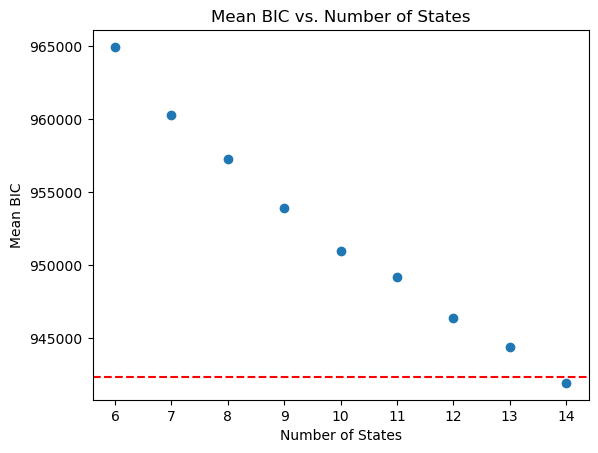

In [137]:
fig, ax = plt.subplots(1, 1)
n_states = [x[0] for x in sorted_by_mean]
means = [x[1]['mean'] for x in sorted_by_mean]
ax.scatter(n_states, means)
if metric == 'full_evidence':
    ax.axhline(y=sorted_by_mean[-1][1]['mean'] - sorted_by_mean[-1][1]['se'], color='r', linestyle='--')
    ax.set_title("Mean Evidence vs. Number of States")
    ax.set_xlabel("Number of States")
    ax.set_ylabel("Mean Evidence")
else:
    ax.axhline(y=sorted_by_mean[0][1]['mean'] + sorted_by_mean[0][1]['se'], color='r', linestyle='--')
    ax.set_title("Mean BIC vs. Number of States")
    ax.set_xlabel("Number of States")
    ax.set_ylabel("Mean BIC")

In [138]:
print(f"Number of states: {metric}")
for n in sorted_states:
    print(f"{n}: {np.mean(hyperparam_CV_no_TDE[n][metric])}")

Number of states: BIC
6: 964966.421777634
7: 960312.5281871294
8: 957299.5879886874
9: 953929.8636823079
10: 950988.2427679903
11: 949167.4252457352
12: 946402.9486155424
13: 944407.687877412
14: 941914.7680313438


### We can load the trained model using <code>model = load("results/model")</code>

## Fit Best Model

In [72]:
optimal_n = 14
best_params = hyperparam_CV_log[optimal_n]['params'][np.argmax(hyperparam_CV_log[n]['mean_CV_test_evidence'])]
best_params

{'sequence_length': 200,
 'batch_size': 57,
 'learning_rate': 0.01,
 'n_epochs': 90}

In [73]:
TDE_status = "no_TDE"
suffix = f"_n{optimal_n}" + TDE_status

config = Config(
    n_states=optimal_n,
    n_channels=full_data.n_channels,
    sequence_length=best_params['sequence_length'],
    learn_means=False,
    learn_covariances=True,
    batch_size=best_params['batch_size'],
    learning_rate=best_params['learning_rate'],
    n_epochs=best_params['n_epochs'],
)

best_model = Model(config)

In [74]:
best_model.random_state_time_course_initialization(full_data, n_epochs=1, n_init=3, verbose=0)
history = best_model.fit(full_data)

2025-10-27 13:07:17.849260: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-10-27 13:07:21.208077: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1/90
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - ll_loss: 9.5531 - loss: 9.5531 - learning_rate: 0.0100 - rho: 0.2853
Epoch 2/90
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - ll_loss: 9.3994 - loss: 9.3994 - learning_rate: 0.0090 - rho: 0.2533
Epoch 3/90
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - ll_loss: 9.2747 - loss: 9.2747 - learning_rate: 0.0082 - rho: 0.2288
Epoch 4/90
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - ll_loss: 9.1733 - loss: 9.1733 - learning_rate: 0.0074 - rho: 0.2094
Epoch 5/90
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - ll_loss: 9.0916 - loss: 9.0916 - learning_rate: 0.0067 - rho: 0.1935
Epoch 6/90
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - ll_loss: 9.0248 - loss: 9.0248 - learning_rate: 0.0061 - rho: 0.1803
Epoch 7/90
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - ll_loss: 8.9704 - loss: 8.9704 - learning_rate: 0.0055 - rho: 0.1691
Epoch 8/90
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - ll_loss: 8.9261 - loss: 8.9261 - learning_rate: 0.0050 - rho: 0.1594
Epoch 9/90
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5

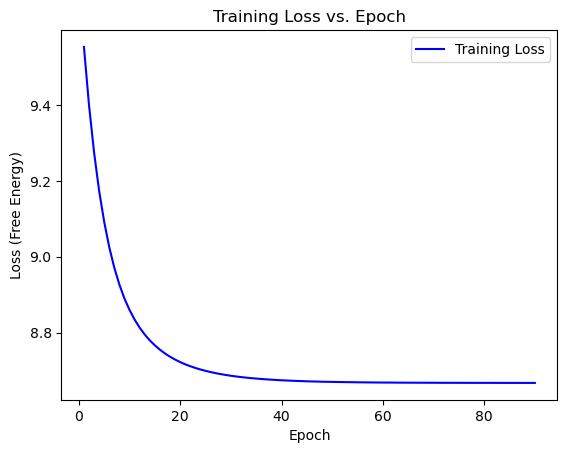

In [75]:
fig, ax = plt.subplots(1, 1)
x = range(1, len(history['loss']) + 1)
ax.plot(x, history['loss'], label="Training Loss", color='blue', linestyle='-')

ax.set_title("Training Loss vs. Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (Free Energy)")
ax.legend()
plt.show()   

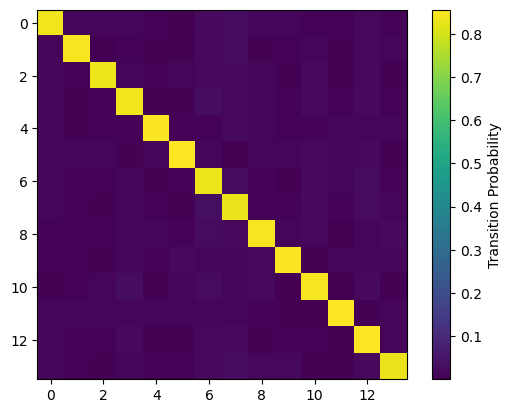

In [157]:
trans_matrix = best_model.get_trans_prob()
plt.imshow(trans_matrix, origin='upper')
plt.colorbar(label='Transition Probability')
plt.show()

In [76]:
alpha = best_model.get_alpha(full_data)

Getting alpha:   0%|          | 0/114 [00:00<?, ?it/s]

2025-10-27 13:07:56.683842: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-10-27 13:07:56.832155: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-10-27 13:07:57.130753: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-10-27 13:07:57.730758: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-10-27 13:07:58.898063: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [77]:
# os.makedirs("results/inf_params", exist_ok=True)

with open("results/inf_params/alpha" + suffix, "wb") as f:
    pickle.dump(alpha, f)

### We can load the inference paramters using <code>alpha = pickle.load(open("results/inf_params/alp.pkl", "rb"))</code>

In [78]:
means, covs = best_model.get_means_covariances()
means.shape, covs.shape

((14, 7), (14, 7, 7))

In [79]:
np.save(f"results/inf_params/means{suffix}.npy", means)
np.save(f"results/inf_params/covs{suffix}.npy", covs)

# HMM Post-Hoc Analysis

In [80]:
type(alpha), len(alpha) # each element of alpha is a subject

(list, 114)

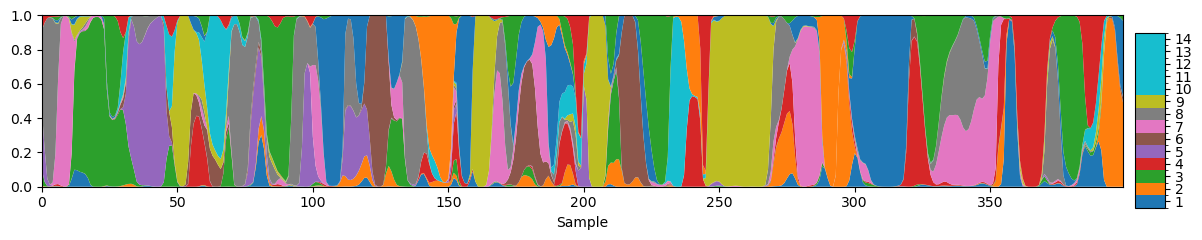

In [81]:
# Plot the state probability time course for the first subject (TR = 2 seconds, so 1000 samples is 2000 seconds)
fig, ax = plotting.plot_alpha(alpha[0], n_samples=1000)

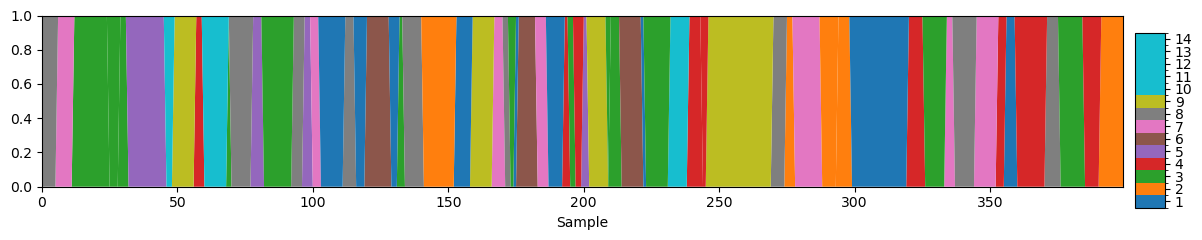

In [82]:
# Hard classify the state probabilities (i.e., for each time point set each probability to either 0 or 1)
stc = modes.argmax_time_courses(alpha) # state time course

fig, ax = plotting.plot_alpha(stc[0], n_samples=1000)

In [83]:
# Fractional occupancy (FO)
fo = modes.fractional_occupancies(stc)
fo.shape

(114, 14)

In [84]:
np.mean(fo, axis=0)

array([0.07322368, 0.05201754, 0.04732456, 0.07951754, 0.04649123,
       0.04885965, 0.11203947, 0.11065789, 0.07039474, 0.04973684,
       0.0822807 , 0.05127193, 0.11964912, 0.05653509])

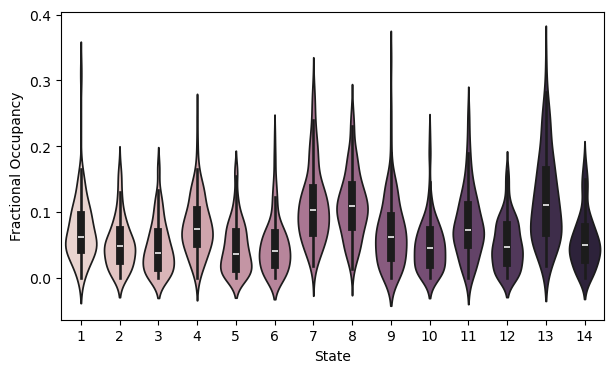

In [85]:
# Plot the distribution of fractional occupancy (FO) across subjects
fig, ax = plotting.plot_violin(fo.T, x_label="State", y_label="Fractional Occupancy")

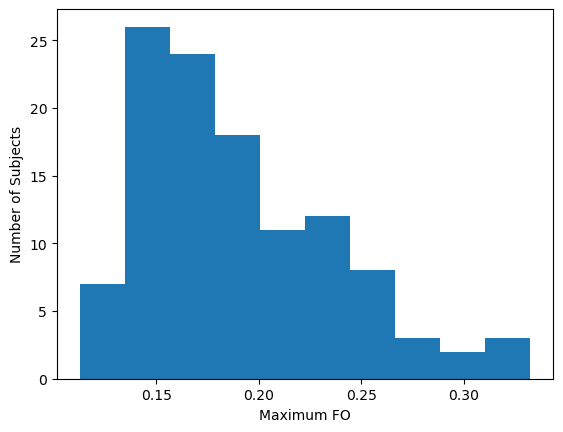

In [106]:
# Plot historgram of maximum FOs to make sure there aren't states dominating subject time courses
fig, ax = plt.subplots(1, 1)
ax.hist(np.max(fo, axis=1))
ax.set_xlabel("Maximum FO")
ax.set_ylabel("Number of Subjects")

plt.show()

[12.41434078 12.98897243 11.06106934 12.53845409 12.69137427 12.73473266
 12.34942368 12.61376757 12.77369181 12.6664787  13.5643028  13.48675856
 14.24167952 11.55815486]


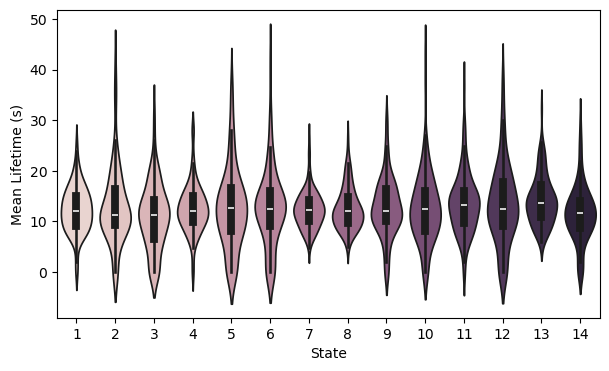

In [107]:
# Calculate mean lifetimes (in seconds)
lt = modes.mean_lifetimes(stc, sampling_frequency=1/2) # TR = 2 s, so sampling_frequency = 1 sample per 2 seconds

# # Convert to ms
# lt *= 1000

# Print the group average
print(np.mean(lt, axis=0))

# Plot distribution across subjects
fig, ax = plotting.plot_violin(lt.T, x_label="State", y_label="Mean Lifetime (s)")

[131.72414369 120.44137427 138.6045809  133.59615706 123.9647452
 122.24954052 104.60861059  98.54765069 117.36779449 130.6531746
 115.84070277 147.38692565 113.5728317  135.44711779]


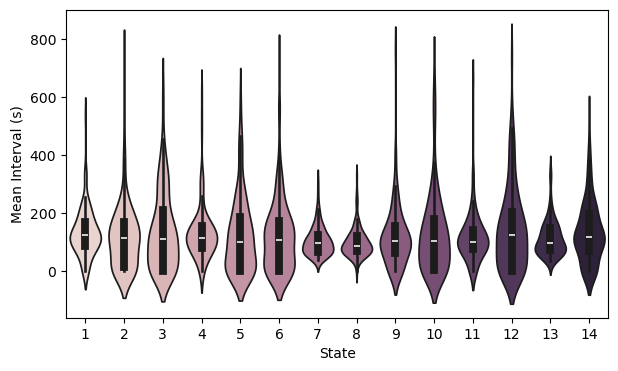

In [108]:
# Calculate mean intervals (in seconds). An interval is the duration between successive visits for a particular state
intv = modes.mean_intervals(stc, sampling_frequency=1/2)

# Print the group average
print(np.mean(intv, axis=0))

# Plot distribution across subjects
fig, ax = plotting.plot_violin(intv.T, x_label="State", y_label="Mean Interval (s)")

[0.00544956 0.00377193 0.00362939 0.00608553 0.00308114 0.00320175
 0.00881579 0.00873904 0.00502193 0.00347588 0.00593202 0.00319079
 0.00805921 0.00446272]


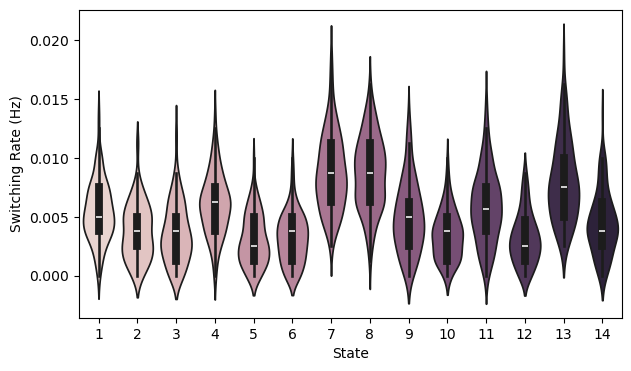

In [109]:
# Calculate the switching rate (Hz). This is defined as the number of state activations per second.
sr = modes.switching_rates(stc, sampling_frequency=1/2)

# Print the group average
print(np.mean(sr, axis=0))

# Plot distribution across subjects
fig, ax = plotting.plot_violin(sr.T, x_label="State", y_label="Switching Rate (Hz)")

## Distribution of fractional occupancy (FO) within each experimental group

In [110]:
groups = {}

for group in np.unique(y):
    groups[group] = {}

In [115]:
# FO means for each experimental group
for group in groups:
    groups[group]['fo'] = fo[np.where(y == group)]
    print(f"FO means for {group}:", np.mean(groups[group]['fo'], axis=0))

print(sum([len(groups[group]['fo']) for group in groups]) == full_data.n_sessions)

FO means for CCI_CIMT_07d: [0.07166667 0.05616667 0.037      0.0745     0.03483333 0.04133333
 0.119      0.12033333 0.07933333 0.0475     0.09183333 0.039
 0.094      0.0935    ]
FO means for CCI_CIMT_21d: [0.0545     0.046      0.06233333 0.1        0.04133333 0.04383333
 0.1305     0.095      0.073      0.03016667 0.09483333 0.04333333
 0.12933333 0.05583333]
FO means for CCI_CIMT_49d: [0.075      0.04133333 0.05866667 0.092      0.0545     0.0545
 0.12283333 0.11466667 0.0775     0.03183333 0.08316667 0.04933333
 0.09116667 0.0535    ]
FO means for CCI_none_07d: [0.0765     0.05716667 0.037      0.08       0.04033333 0.03733333
 0.12883333 0.11983333 0.05233333 0.05216667 0.08366667 0.06033333
 0.12016667 0.05433333]
FO means for CCI_none_21d: [0.08692308 0.03384615 0.06403846 0.09557692 0.05480769 0.03346154
 0.10173077 0.10519231 0.07884615 0.05       0.07461538 0.06096154
 0.11711538 0.04288462]
FO means for CCI_none_49d: [0.076      0.05566667 0.04966667 0.056      0.07133333 0

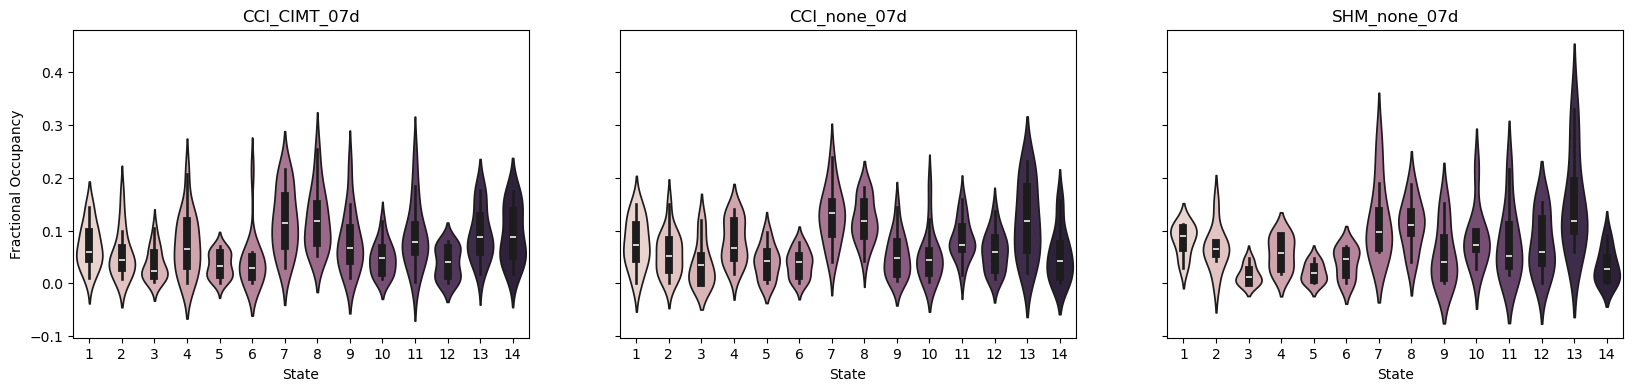

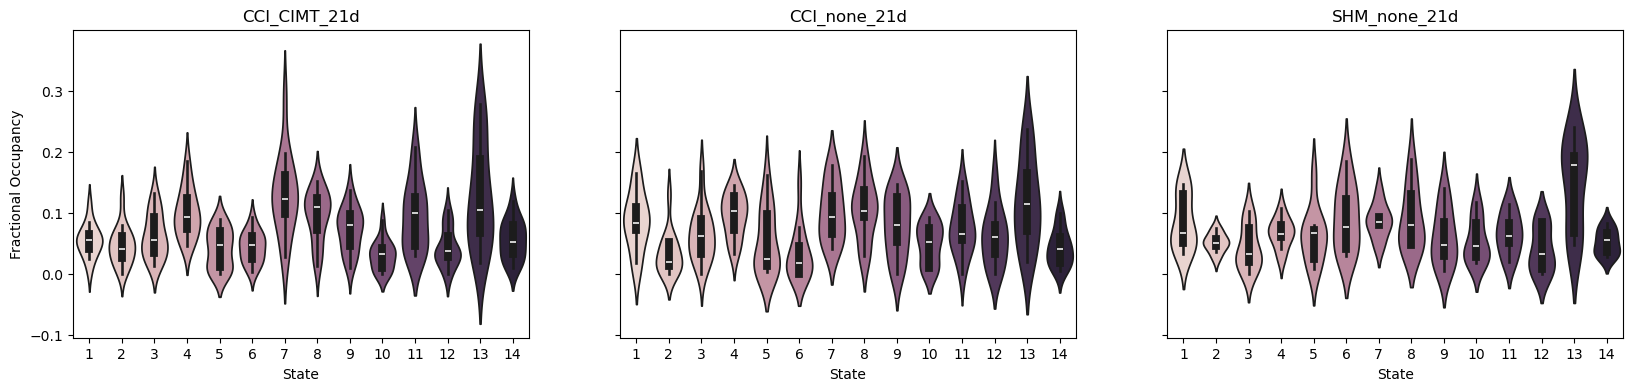

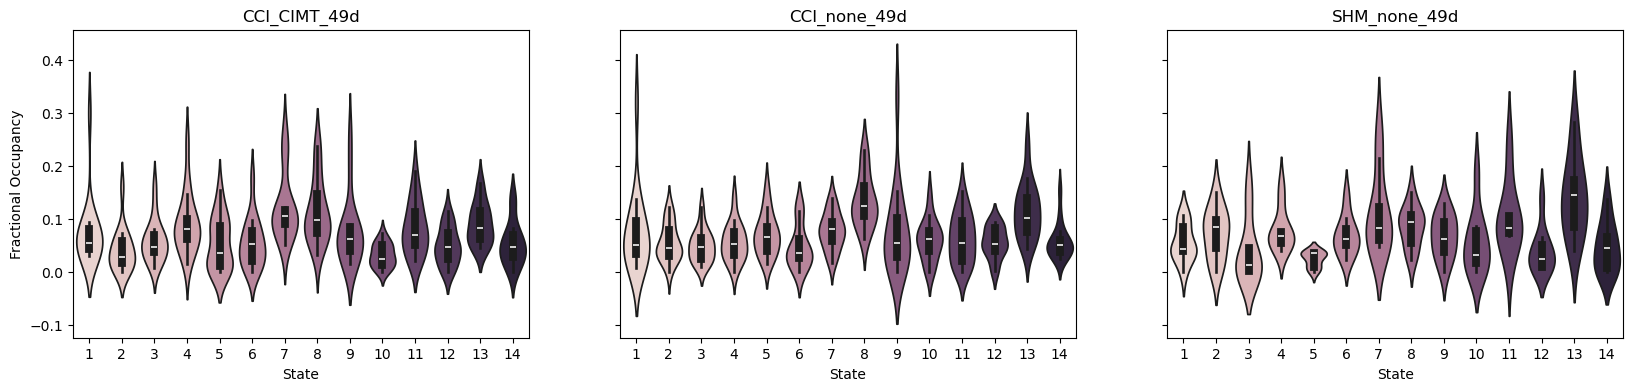

In [116]:
for PID in ['07d', '21d', '49d']:
    fig, ax = plt.subplots(1, 3, sharey=True, figsize=(20, 4))
    plotting.plot_violin(groups['CCI_CIMT_' + PID]['fo'].T, x_label="State", y_label="Fractional Occupancy", title="CCI_CIMT_" + PID, ax=ax[0])
    plotting.plot_violin(groups['CCI_none_' + PID]['fo'].T, x_label="State", y_label="Fractional Occupancy", title="CCI_none_" + PID, ax=ax[1])
    plotting.plot_violin(groups['SHM_none_' + PID]['fo'].T, x_label="State", y_label="Fractional Occupancy", title="SHM_none_" + PID, ax=ax[2])

## Mean state lifetimes within each experimental group

In [117]:
# State time course (STC) for each experimental group
for group in groups:
    groups[group]['stc'] = [stc[i] for i in range(len(stc)) if i in np.where(y == group)[0]]

print(sum([len(groups[group]['stc']) for group in groups]) == full_data.n_sessions)

True


In [118]:
# Calculate mean lifetimes (in seconds) for each experimental group
for group in groups:
    groups[group]['lt'] = modes.mean_lifetimes(groups[group]['stc'], sampling_frequency=1/2) # TR = 2 s, so sampling_frequency = 1 sample per 2 seconds

print(sum([len(groups[group]['lt']) for group in groups]) == full_data.n_sessions)

True


CCI_CIMT_07d: [12.46920635 11.14074074  9.52888889  9.98891775 11.46666667 10.91777778
 12.04958153 12.93733045 13.97121693 12.95555556 13.30174603 12.44222222
 12.62039442 13.27261183]
CCI_CIMT_21d: [11.47555556 11.47777778 11.80222222 13.07375661  9.98666667 17.04444444
 13.49243386 11.84635883 11.97174603  8.96666667 12.46294372 12.02444444
 13.94025641 11.45650794]
CCI_CIMT_49d: [12.97676768 11.61481481 13.70253968 12.68433862 11.71111111 12.57666667
 13.54464646 14.3096744  15.2431746  11.90666667 13.61       12.81111111
 13.79407407 11.76190476]
CCI_none_07d: [11.90396825 12.53777778  6.63873016 13.58952381 10.41111111 11.78888889
 13.53779406 11.89415584 12.44920635 11.32555556 13.90782107 13.24666667
 14.18857143 10.05666667]
CCI_none_21d: [11.84304029 14.82051282 12.76739927 14.37454212 14.66923077  8.1032967
 11.98412698 11.76509602 11.92374847 12.56410256 13.06666667 13.78498168
 12.50302475 11.19230769]
CCI_none_49d: [13.35444444 12.20666667 15.55333333 11.47555556 18.98222

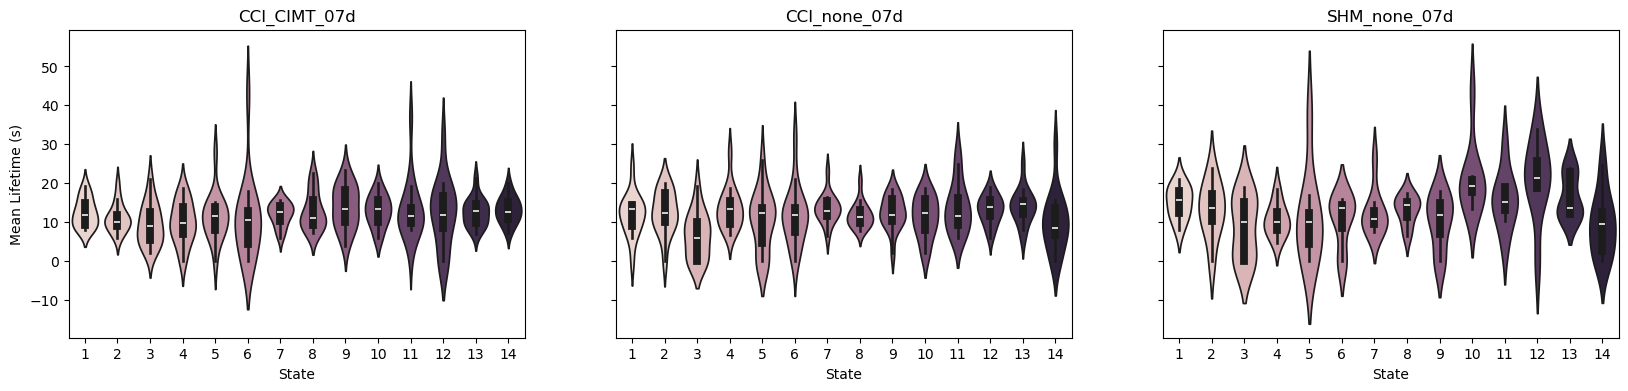

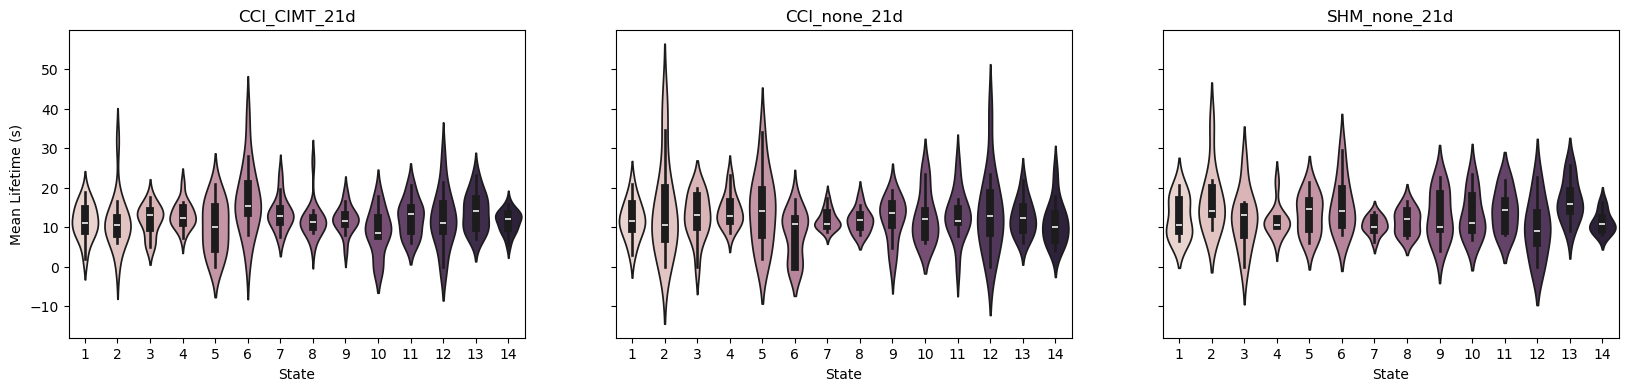

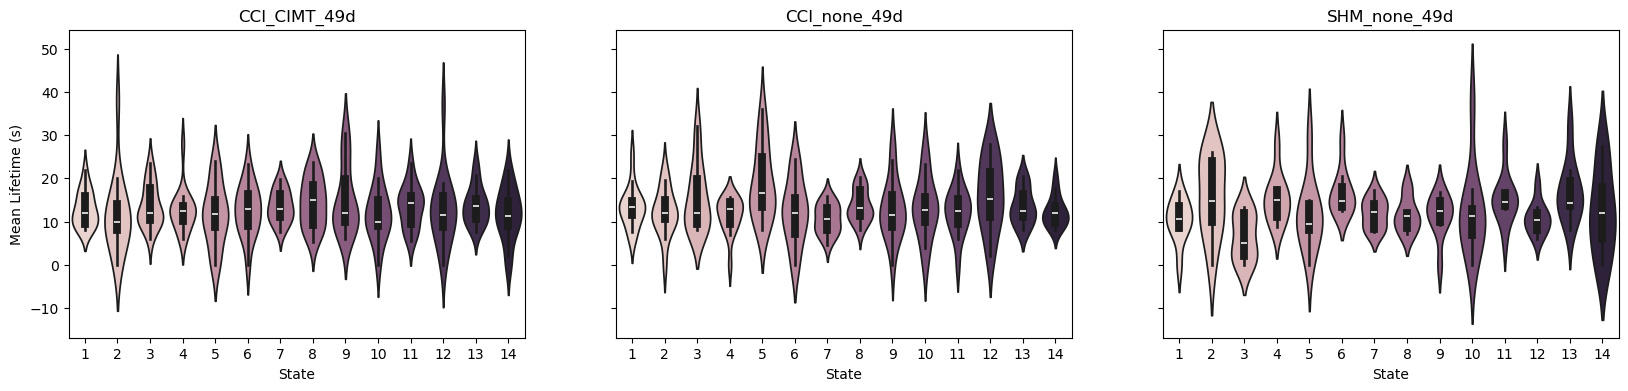

In [119]:
for group, attr in groups.items():
    # Print the group average
    print(f"{group}: {np.mean(attr['lt'], axis=0)}")

for PID in ['07d', '21d', '49d']:
    fig, ax = plt.subplots(1, 3, sharey=True, figsize=(20, 4))
    plotting.plot_violin(groups['CCI_CIMT_' + PID]['lt'].T, x_label="State", y_label="Mean Lifetime (s)", title="CCI_CIMT_" + PID, ax=ax[0])
    plotting.plot_violin(groups['CCI_none_' + PID]['lt'].T, x_label="State", y_label="Mean Lifetime (s)", title="CCI_none_" + PID, ax=ax[1])
    plotting.plot_violin(groups['SHM_none_' + PID]['lt'].T, x_label="State", y_label="Mean Lifetime (s)", title="SHM_none_" + PID, ax=ax[2])

## Mean interstate intervals within each experimental group

In [120]:
# Calculate mean intervals (in seconds) for each experimental group. An interval is the duration between successive visits for a particular state
for group in groups:
    groups[group]['intv'] = modes.mean_intervals(groups[group]['stc'], sampling_frequency=1/2)

print(sum([len(groups[group]['intv']) for group in groups]) == full_data.n_sessions)

True


CCI_CIMT_07d: [127.16793651 131.52444444 165.27777778 134.27111111  72.95111111
 102.84444444  99.15544974  99.03730159 145.1        124.84
 107.0626455  110.68888889 110.73650794 115.39936508]
CCI_CIMT_21d: [106.79492063 163.69777778 193.62888889 118.24333333 121.77777778
  69.28888889  91.41042328 125.02153439 116.00888889 117.64444444
 125.79269841 221.1        117.45036075 108.93301587]
CCI_CIMT_49d: [138.73111111  67.11444444 182.25555556 145.87222222 106.57333333
 105.56        92.32925926 112.38746032 150.07111111  76.65555556
 110.60190476 193.98730159 134.05666667 158.35555556]
CCI_none_07d: [117.95809524 133.52666667  83.09111111 104.85873016 118.92
 116.81111111 100.02181818  92.04137566  86.73333333 134.08857143
 122.11555556 137.46444444 126.05658009 137.56793651]
CCI_none_21d: [147.88534799  29.15384615 153.48717949 140.17912088  79.29230769
  83.3974359  137.46120973  96.13881119 107.74212454 111.66666667
 149.07692308 181.03846154  99.45301365 155.16923077]
CCI_none_49d

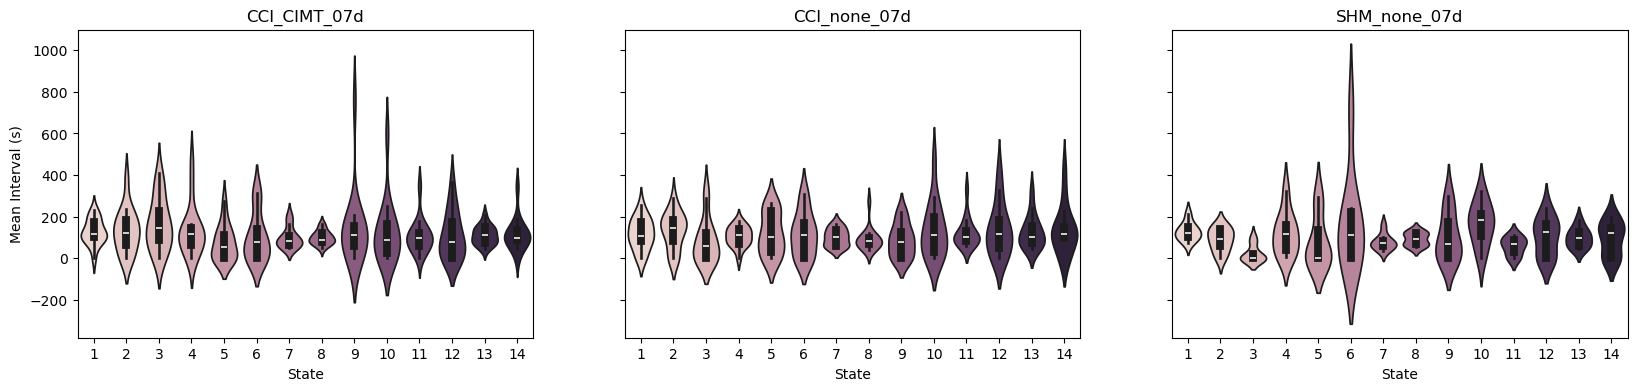

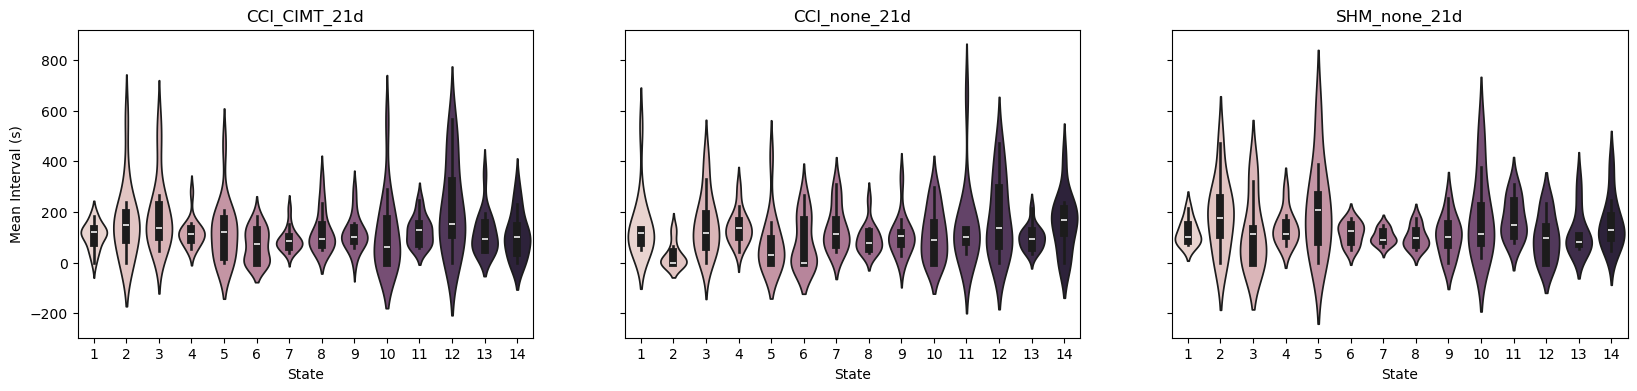

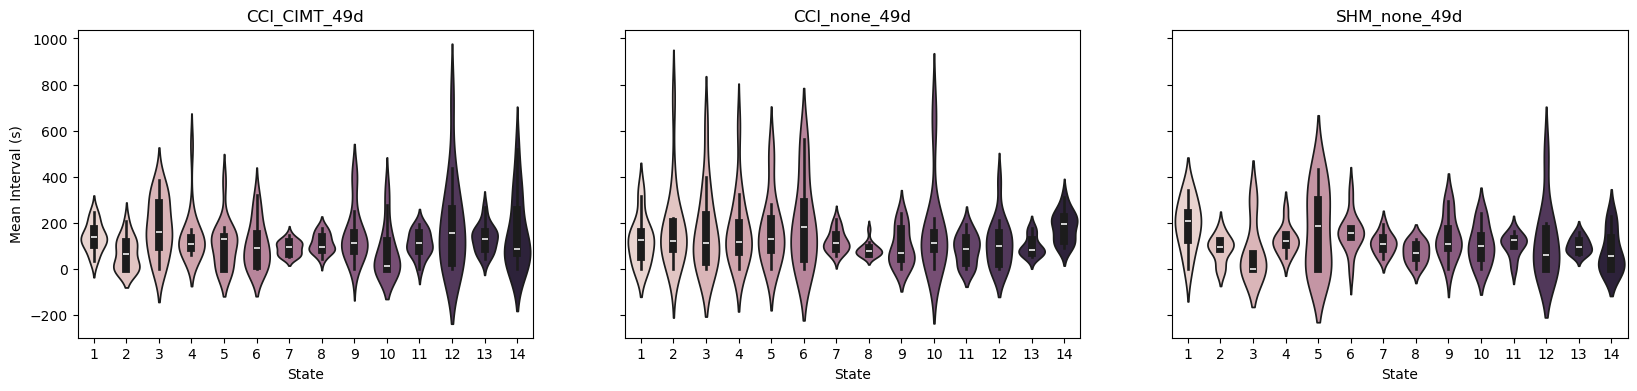

In [121]:
for group, attr in groups.items():
    # Print the group average
    print(f"{group}: {np.mean(attr['intv'], axis=0)}")

for PID in ['07d', '21d', '49d']:
    fig, ax = plt.subplots(1, 3, sharey=True, figsize=(20, 4))
    plotting.plot_violin(groups['CCI_CIMT_' + PID]['intv'].T, x_label="State", y_label="Mean Interval (s)", title="CCI_CIMT_" + PID, ax=ax[0])
    plotting.plot_violin(groups['CCI_none_' + PID]['intv'].T, x_label="State", y_label="Mean Interval (s)", title="CCI_none_" + PID, ax=ax[1])
    plotting.plot_violin(groups['SHM_none_' + PID]['intv'].T, x_label="State", y_label="Mean Interval (s)", title="SHM_none_" + PID, ax=ax[2])

In [141]:
subj_means, subj_covs = best_model.dual_estimation(full_data, alpha=alpha)
subj_means.shape, subj_covs.shape

Dual estimation:   0%|          | 0/114 [00:00<?, ?it/s]

((8, 7), (114, 8, 7, 7))

In [142]:
os.makedirs("results/dual_estimates", exist_ok=True)
np.save(f"results/dual_estimates/subj_means{suffix}.npy", subj_means)
np.save(f"results/dual_estimates/subj_covs{suffix}.npy", subj_covs)

Other considerations:
- Need to verify validity of ICL calculation, could be more powerful than BIC
- Maybe test reproducibility of states (idk how, maybe using similarity of covariance matrices of emissions models?)?
- Try ICA or eigendecomposition of phase coherency matrix, try stim data